# 1D-CNN Speech Classification — Baghel et al. (2019) Architecture

**Reference:** Baghel, S., Bhattacharjee, M., Prasanna, S.R.M., Guha, P. (2019).
*"Shouted and Normal Speech Classification Using 1D CNN."* PReMI 2019, LNCS vol. 11942, pp. 472-480.

## What the paper actually specifies (confirmed from the published chapter, not guessed)

- **Input is NOT the raw waveform.** Each utterance is split into overlapping frames of
  **20 ms with a 10 ms shift** at 16 kHz -> 320 samples/frame. The frame's **DFT magnitude
  spectrum** is computed and only the **first 160 bins** (half-spectrum, since the signal is
  real) are kept. So the network's input is a **160-dimensional magnitude-spectrum vector
  per frame**, not a time-domain sample sequence.
- **Two 1D convolutional layers**: 32 kernels then 64 kernels, kernel size 7x1 each, ReLU,
  **valid** (no) padding, stride 1. `160 -> 154 -> 148` along the feature axis.
- **One max-pooling stage**: 2x1, stride 2 -> `148 -> 74`.
- **Flatten** -> `74 x 64 = 4736` nodes (this exact number is reproduced below as a sanity
  check -- if it doesn't come out to 4736, the architecture has been changed).
- **Three dense layers**: `4736 -> 200 -> 20 -> num_classes`, ReLU on the two hidden dense
  layers, softmax on the output layer (handled implicitly by `CrossEntropyLoss` here).
- **Training**: Adam, learning rate `1e-4`, cross-entropy loss, batch size **512**, up to
  **150 epochs**.
- The original paper is a **binary** task (shouted vs. normal speech) at the **frame**
  level. Adaptations needed for our problem are listed below.

## Adaptations made for our 4-class, clip-level task (clearly flagged, not silently done)

1. **Output layer changed from 2 -> 4 classes** (Command / Conversation / Numeric / Read) --
   everything else in the architecture is untouched.
2. **Frame -> clip aggregation.** Our labels exist at the 1-second-clip level, not the frame
   level, so every frame inherits its parent clip's label for training, and at evaluation
   time we aggregate all of a clip's frame-level softmax outputs (mean of the softmax
   probabilities) into one clip-level prediction. The paper's own task was already framed at
   whatever unit they evaluated on; this aggregation step is our addition, not theirs.
3. **Per-frequency-bin standardization** (zero-mean/unit-variance, fit on the training set)
   is applied to the 160-d magnitude-spectrum vectors before they enter the network. The
   paper does not mention any input normalization; raw magnitude-spectrum values can be
   large and uneven across frequency bins, which makes `lr=1e-4` Adam training slow/unstable
   without it. This is a documented deviation, not part of the original method.
4. **Early stopping on validation accuracy** (patience-based) instead of a fixed 150 epochs.
   The paper trains for a fixed 150 epochs with no validation-based stopping described. We
   keep 150 as the epoch *ceiling* but stop early if validation stops improving -- flagged
   here so it isn't mistaken for the paper's own protocol.
5. **No windowing function** is applied before the DFT (rectangular framing), matching what
   the paper's equations describe literally. A Hamming/Hann window is a common practical
   improvement but isn't in the paper, so it's left out here; a commented-out line shows
   where to add it if you want to test that variant.

This notebook follows the same dataset, leakage-check, dedup, and reporting conventions as
the earlier Wav2Vec2 / WavLM / HuBERT notebooks so results are directly comparable -- this
model is trained **from scratch** (no self-supervised pretraining), which is the point of
including it: it's a lightweight classical-DSP-feature baseline against the transformer
backbones.

As before: not run on my end (no GPU/dataset here) -- no output numbers below are real.


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_train.npy


In [2]:
# ============================================================
# 0. Environment
# ============================================================
!pip install -q scikit-learn scipy


In [3]:
# ============================================================
# 1. Imports & Reproducibility
# ============================================================
import os
import gc
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from scipy.stats import chi2
import random


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
# ============================================================
# 2. Config -- values taken directly from the paper unless noted
# ============================================================
SR = 16000
NUM_CLASSES = 4
CLASS_NAMES = ["Command", "Conversation", "Numeric", "Read"]

FRAME_MS = 20          # paper: 20 ms frames
HOP_MS = 10            # paper: 10 ms shift
FRAME_LEN = int(SR * FRAME_MS / 1000)   # 320 samples
HOP_LEN = int(SR * HOP_MS / 1000)       # 160 samples
N_FREQ = 160           # paper: first 160 bins of the magnitude spectrum kept

CONV1_CHANNELS = 32    # paper
CONV2_CHANNELS = 64    # paper
KERNEL_SIZE = 7        # paper
POOL_SIZE = 2          # paper

FC1_UNITS = 200        # paper
FC2_UNITS = 20         # paper

BATCH_SIZE = 512       # paper
LR = 1e-4              # paper
MAX_EPOCHS = 150       # paper ceiling
PATIENCE = 8           # NOT in the paper -- early-stopping addition, see intro

DATA16_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit"
DATA1_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit"
OUT_DIR = "/kaggle/working/results_1dcnn"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Frame length: {FRAME_LEN} samples | Hop: {HOP_LEN} samples | Input dim: {N_FREQ}")


Frame length: 320 samples | Hop: 160 samples | Input dim: 160


In [5]:
# ============================================================
# 3. Data utilities -- load / leakage-check-and-fix / describe
# ============================================================
def load_split(data_dir, x_name, y_name):
    X = np.load(os.path.join(data_dir, x_name))
    y = np.load(os.path.join(data_dir, y_name))
    return X, y


def describe_dataset(name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    print("Train:", X_train.shape, y_train.shape)
    print("Val  :", X_val.shape, y_val.shape)
    print("Test :", X_test.shape, y_test.shape)


def _waveform_hashes(X):
    Xf = np.squeeze(X).astype(np.float32)
    return [hash(Xf[i].tobytes()) for i in range(len(Xf))]


def check_leakage(X_train, X_val, X_test):
    h_train, h_val, h_test = set(_waveform_hashes(X_train)), set(_waveform_hashes(X_val)), set(_waveform_hashes(X_test))
    lv, lt, vt = h_train & h_val, h_train & h_test, h_val & h_test
    print(f"Duplicate waveforms train∩val : {len(lv)}")
    print(f"Duplicate waveforms train∩test: {len(lt)}")
    print(f"Duplicate waveforms val∩test  : {len(vt)}")
    return lv, lt, vt


def dedupe_train_against_val_test(X_train, y_train, X_val, X_test, tag: str):
    h_train = _waveform_hashes(X_train)
    h_blocked = set(_waveform_hashes(X_val)) | set(_waveform_hashes(X_test))
    keep_mask = np.array([h not in h_blocked for h in h_train])
    n_removed = int((~keep_mask).sum())
    print(f"[{tag}] Removed {n_removed} train sample(s) duplicating a val/test waveform."
          if n_removed else f"[{tag}] No train/val/test duplicates found.")
    return X_train[keep_mask], y_train[keep_mask]


In [6]:
# ============================================================
# 4. Feature extraction -- framing + DFT magnitude spectrum (paper Sec. 2)
# ============================================================
def frame_signal(x, frame_len=FRAME_LEN, hop_len=HOP_LEN):
    """Rectangular framing (no window -- see intro note). Returns (n_frames, frame_len)."""
    n_frames = 1 + (len(x) - frame_len) // hop_len
    idx = np.arange(frame_len)[None, :] + hop_len * np.arange(n_frames)[:, None]
    frames = x[idx]
    # Optional (NOT in the paper) -- uncomment to test a Hamming-windowed variant:
    # frames = frames * np.hamming(frame_len)[None, :]
    return frames


def extract_spectral_frames(X_clips, n_freq=N_FREQ):
    """For each clip: frame it, take the DFT magnitude spectrum, keep the first
    `n_freq` bins. Returns (X_feat [n_frames_total, n_freq], clip_ids [n_frames_total])."""
    X_clips = np.squeeze(X_clips).astype(np.float32)
    feats, clip_ids = [], []
    for i in range(len(X_clips)):
        frames = frame_signal(X_clips[i])
        spec = np.abs(np.fft.rfft(frames, axis=1))[:, :n_freq]
        feats.append(spec)
        clip_ids.append(np.full(spec.shape[0], i, dtype=np.int64))
    X_feat = np.concatenate(feats, axis=0).astype(np.float32)
    clip_ids = np.concatenate(clip_ids)
    return X_feat, clip_ids


def fit_standardizer(X_feat):
    mean = X_feat.mean(axis=0, keepdims=True)
    std = X_feat.std(axis=0, keepdims=True) + 1e-7
    return mean, std


def apply_standardizer(X_feat, mean, std):
    return (X_feat - mean) / std


In [7]:
# ============================================================
# 5. Dataset / Model / Train / Eval utilities
# ============================================================
class FrameDataset(Dataset):
    def __init__(self, X_feat, y_frame):
        self.X = X_feat.astype(np.float32)
        self.y = y_frame.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)


class Baghel1DCNN(nn.Module):
    """Exact architecture from Baghel et al. (2019), Fig. 1 -- only the final
    layer's output size differs (2 -> NUM_CLASSES) for our 4-class task."""

    def __init__(self, num_classes: int, n_freq: int = N_FREQ):
        super().__init__()
        self.conv1 = nn.Conv1d(1, CONV1_CHANNELS, kernel_size=KERNEL_SIZE)
        self.conv2 = nn.Conv1d(CONV1_CHANNELS, CONV2_CHANNELS, kernel_size=KERNEL_SIZE)
        self.pool = nn.MaxPool1d(kernel_size=POOL_SIZE, stride=POOL_SIZE)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_freq)
            flat_dim = self.pool(self.relu(self.conv2(self.relu(self.conv1(dummy))))).numel()
        assert flat_dim == 4736, f"Expected flatten dim 4736 (paper), got {flat_dim} -- check N_FREQ/kernel/pool sizes."
        print(f"Flatten dimension: {flat_dim} (paper reports 74 x 64 = 4736 -- match confirmed)")

        self.fc1 = nn.Linear(flat_dim, FC1_UNITS)
        self.fc2 = nn.Linear(FC1_UNITS, FC2_UNITS)
        self.fc3 = nn.Linear(FC2_UNITS, num_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (B, 1, n_freq)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)  # logits; softmax handled by CrossEntropyLoss


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total


@torch.no_grad()
def evaluate_frames(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        logits = model(feats)
        loss = criterion(logits, labels)
        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total


@torch.no_grad()
def predict_clip_level(model, X_feat, clip_ids, n_clips, batch_size=1024):
    """Runs the model over all frames, mean-pools softmax probabilities per
    clip (frame -> clip aggregation, see intro note #2), returns clip-level
    predictions, probabilities, and per-frame predictions."""
    model.eval()
    n_frames = len(X_feat)
    all_probs = np.zeros((n_frames, NUM_CLASSES), dtype=np.float32)
    for start in range(0, n_frames, batch_size):
        end = min(start + batch_size, n_frames)
        feats = torch.tensor(X_feat[start:end], dtype=torch.float32).to(device)
        logits = model(feats)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs[start:end] = probs

    clip_probs = np.zeros((n_clips, NUM_CLASSES), dtype=np.float32)
    counts = np.zeros(n_clips, dtype=np.int64)
    for i in range(n_frames):
        clip_probs[clip_ids[i]] += all_probs[i]
        counts[clip_ids[i]] += 1
    clip_probs = clip_probs / np.maximum(counts, 1)[:, None]
    clip_preds = clip_probs.argmax(axis=1)
    return clip_preds, clip_probs


def full_clip_report(y_true_clip, y_pred_clip, tag: str):
    acc = accuracy_score(y_true_clip, y_pred_clip)
    precision = precision_score(y_true_clip, y_pred_clip, average="macro", zero_division=0)
    recall = recall_score(y_true_clip, y_pred_clip, average="macro", zero_division=0)
    f1 = f1_score(y_true_clip, y_pred_clip, average="macro", zero_division=0)

    print("=" * 50)
    print(f"{tag} -- Clip-Level Test Performance")
    print("=" * 50)
    print(f"Accuracy   : {acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 (macro) : {f1:.4f}\n")
    print(classification_report(y_true_clip, y_pred_clip, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true_clip, y_pred_clip)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix -- {tag}")
    plt.tight_layout()
    plt.show()

    return {"tag": tag, "accuracy": acc, "precision": precision, "recall": recall, "f1_macro": f1,
            "preds": y_pred_clip, "labels": y_true_clip}


def plot_history(history_rows, tag: str):
    h = pd.DataFrame(history_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["epoch"], h["train_acc"], label="train (frame-level)")
    axes[0].plot(h["epoch"], h["val_acc"], label="val (frame-level)")
    axes[0].set_title(f"{tag} -- Frame Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["epoch"], h["train_loss"], label="train")
    axes[1].plot(h["epoch"], h["val_loss"], label="val")
    axes[1].set_title(f"{tag} -- Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return h


---
# PART A -- 16-bit condition
---

In [8]:
# ============================================================
# [16-bit] 1. Load data + leakage check + dedupe
# ============================================================
X_train_16, y_train_16 = load_split(DATA16_DIR, "X_train.npy", "y_train.npy")
X_val_16, y_val_16 = load_split(DATA16_DIR, "X_val.npy", "y_val.npy")
X_test_16, y_test_16 = load_split(DATA16_DIR, "X_test.npy", "y_test.npy")

describe_dataset("16-bit", X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16)
check_leakage(X_train_16, X_val_16, X_test_16)
X_train_16, y_train_16 = dedupe_train_against_val_test(X_train_16, y_train_16, X_val_16, X_test_16, tag="16-bit")


Dataset: 16-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 0
Duplicate waveforms val∩test  : 0
[16-bit] No train/val/test duplicates found.


In [9]:
# ============================================================
# [16-bit] 2. Frame extraction + standardization + loaders
# ============================================================
Xf_train_16, ids_train_16 = extract_spectral_frames(X_train_16)
Xf_val_16, ids_val_16 = extract_spectral_frames(X_val_16)
Xf_test_16, ids_test_16 = extract_spectral_frames(X_test_16)

print(f"Frames -- train: {Xf_train_16.shape}, val: {Xf_val_16.shape}, test: {Xf_test_16.shape}")
print(f"Avg frames/clip: {len(Xf_train_16) / len(X_train_16):.1f}")

mean_16, std_16 = fit_standardizer(Xf_train_16)   # fit on TRAIN only
Xf_train_16 = apply_standardizer(Xf_train_16, mean_16, std_16)
Xf_val_16 = apply_standardizer(Xf_val_16, mean_16, std_16)
Xf_test_16 = apply_standardizer(Xf_test_16, mean_16, std_16)

y_frame_train_16 = y_train_16[ids_train_16]
y_frame_val_16 = y_val_16[ids_val_16]

train_loader_16 = DataLoader(FrameDataset(Xf_train_16, y_frame_train_16), batch_size=BATCH_SIZE, shuffle=True)
val_loader_16 = DataLoader(FrameDataset(Xf_val_16, y_frame_val_16), batch_size=BATCH_SIZE, shuffle=False)


Frames -- train: (950400, 160), val: (118800, 160), test: (118800, 160)
Avg frames/clip: 99.0


In [10]:
# ============================================================
# [16-bit] 3. Model + training (single stage -- trained from scratch)
# ============================================================
seed_everything(SEED)
model_16bit = Baghel1DCNN(NUM_CLASSES).to(device)
optimizer_16bit = torch.optim.Adam(model_16bit.parameters(), lr=LR)
criterion_16bit = nn.CrossEntropyLoss()

best_val_acc_16 = 0.0
best_state_16 = None
history_16 = []
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit)
    va_loss, va_acc = evaluate_frames(model_16bit, val_loader_16, criterion_16bit)

    history_16.append({"epoch": epoch + 1, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va_loss, "val_acc": va_acc})
    print(f"[16-bit] Epoch {epoch+1}/{MAX_EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_1dcnn_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val frame-acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> early stopping at epoch {epoch+1} (paper ceiling was {MAX_EPOCHS})")
            break

model_16bit.load_state_dict(best_state_16)
print(f"\n[16-bit] Training finished. Best validation frame-accuracy: {best_val_acc_16:.4f}")


Flatten dimension: 4736 (paper reports 74 x 64 = 4736 -- match confirmed)
[16-bit] Epoch 1/150 | Train Loss 0.8217 Acc 0.6622 | Val Loss 0.6463 Acc 0.7404
  -> new best (Val frame-acc = 0.7404)
[16-bit] Epoch 2/150 | Train Loss 0.6048 Acc 0.7597 | Val Loss 0.5537 Acc 0.7786
  -> new best (Val frame-acc = 0.7786)
[16-bit] Epoch 3/150 | Train Loss 0.5318 Acc 0.7886 | Val Loss 0.5115 Acc 0.7955
  -> new best (Val frame-acc = 0.7955)
[16-bit] Epoch 4/150 | Train Loss 0.4865 Acc 0.8078 | Val Loss 0.5054 Acc 0.8033
  -> new best (Val frame-acc = 0.8033)
[16-bit] Epoch 5/150 | Train Loss 0.4553 Acc 0.8209 | Val Loss 0.4508 Acc 0.8209
  -> new best (Val frame-acc = 0.8209)
[16-bit] Epoch 6/150 | Train Loss 0.4344 Acc 0.8312 | Val Loss 0.4295 Acc 0.8285
  -> new best (Val frame-acc = 0.8285)
[16-bit] Epoch 7/150 | Train Loss 0.4142 Acc 0.8392 | Val Loss 0.4143 Acc 0.8418
  -> new best (Val frame-acc = 0.8418)
[16-bit] Epoch 8/150 | Train Loss 0.4017 Acc 0.8454 | Val Loss 0.4120 Acc 0.8477
  -> 

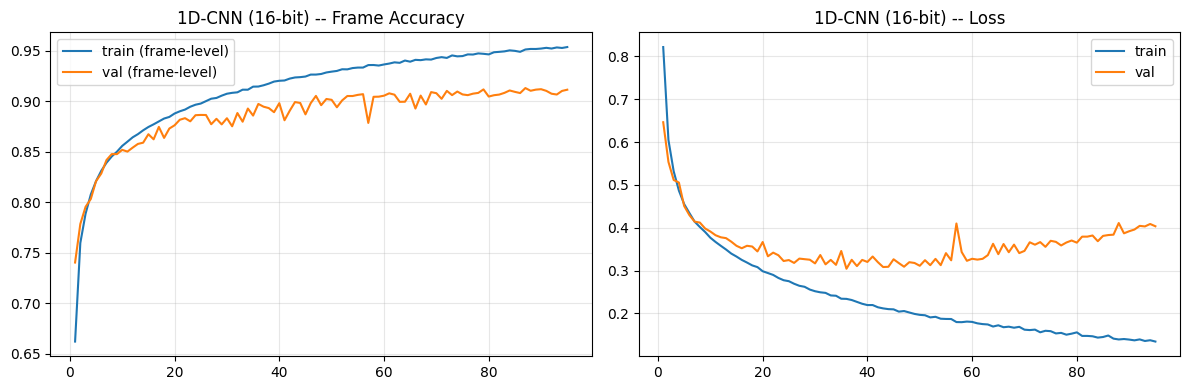

In [11]:
# ============================================================
# [16-bit] 4. Training curves
# ============================================================
hist_df_16 = plot_history(history_16, "1D-CNN (16-bit)")


1D-CNN (16-bit) -- Clip-Level Test Performance
Accuracy   : 0.9900
Precision  : 0.9900
Recall     : 0.9900
F1 (macro) : 0.9900

              precision    recall  f1-score   support

     Command     0.9865    0.9767    0.9816       300
Conversation     1.0000    1.0000    1.0000       300
     Numeric     0.9901    1.0000    0.9950       300
        Read     0.9833    0.9833    0.9833       300

    accuracy                         0.9900      1200
   macro avg     0.9900    0.9900    0.9900      1200
weighted avg     0.9900    0.9900    0.9900      1200



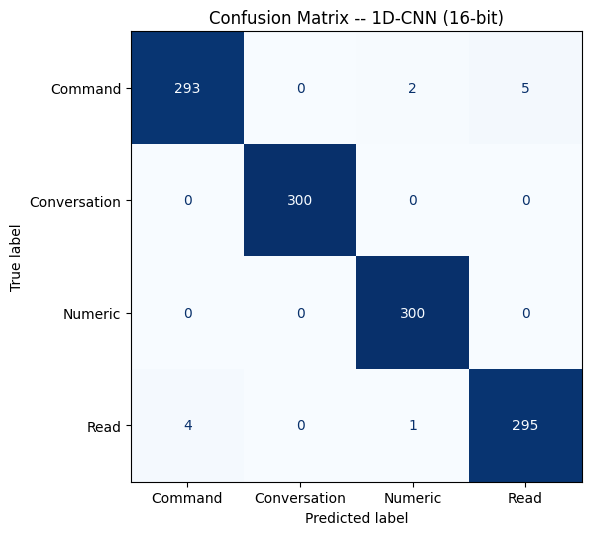

In [12]:
# ============================================================
# [16-bit] 5. Clip-level test evaluation (full report)
# ============================================================
preds_clip_16, probs_clip_16 = predict_clip_level(model_16bit, Xf_test_16, ids_test_16, n_clips=len(X_test_16))
report_16bit = full_clip_report(y_test_16, preds_clip_16, tag="1D-CNN (16-bit)")


In [13]:
# ============================================================
# [16-bit] 6. Free memory before the 1-bit run
# ============================================================
del Xf_train_16, Xf_val_16
gc.collect()
torch.cuda.empty_cache()
print("16-bit section complete.")


16-bit section complete.


---
# PART B -- 1-bit condition
---

In [14]:
# ============================================================
# [1-bit] 1. Load data + leakage check + dedupe
# ============================================================
X_train_1, y_train_1 = load_split(DATA1_DIR, "X_1bit_train.npy", "y_1bit_train.npy")
X_val_1, y_val_1 = load_split(DATA1_DIR, "X_1bit_val.npy", "y_1bit_val.npy")
X_test_1, y_test_1 = load_split(DATA1_DIR, "X_1bit_test.npy", "y_1bit_test.npy")

X_train_1 = np.squeeze(X_train_1)[..., np.newaxis]
X_val_1 = np.squeeze(X_val_1)[..., np.newaxis]
X_test_1 = np.squeeze(X_test_1)[..., np.newaxis]

describe_dataset("1-bit", X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1)
check_leakage(X_train_1, X_val_1, X_test_1)
X_train_1, y_train_1 = dedupe_train_against_val_test(X_train_1, y_train_1, X_val_1, X_test_1, tag="1-bit")


Dataset: 1-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 1
Duplicate waveforms val∩test  : 0
[1-bit] Removed 5 train sample(s) duplicating a val/test waveform.


In [15]:
# ============================================================
# [1-bit] 2. Frame extraction + standardization + loaders
# ============================================================
Xf_train_1, ids_train_1 = extract_spectral_frames(X_train_1)
Xf_val_1, ids_val_1 = extract_spectral_frames(X_val_1)
Xf_test_1, ids_test_1 = extract_spectral_frames(X_test_1)

print(f"Frames -- train: {Xf_train_1.shape}, val: {Xf_val_1.shape}, test: {Xf_test_1.shape}")
print(f"Avg frames/clip: {len(Xf_train_1) / len(X_train_1):.1f}")

mean_1, std_1 = fit_standardizer(Xf_train_1)   # fit on TRAIN only
Xf_train_1 = apply_standardizer(Xf_train_1, mean_1, std_1)
Xf_val_1 = apply_standardizer(Xf_val_1, mean_1, std_1)
Xf_test_1 = apply_standardizer(Xf_test_1, mean_1, std_1)

y_frame_train_1 = y_train_1[ids_train_1]
y_frame_val_1 = y_val_1[ids_val_1]

train_loader_1 = DataLoader(FrameDataset(Xf_train_1, y_frame_train_1), batch_size=BATCH_SIZE, shuffle=True)
val_loader_1 = DataLoader(FrameDataset(Xf_val_1, y_frame_val_1), batch_size=BATCH_SIZE, shuffle=False)


Frames -- train: (949905, 160), val: (118800, 160), test: (118800, 160)
Avg frames/clip: 99.0


In [16]:
# ============================================================
# [1-bit] 3. Model + training (single stage -- trained from scratch)
# ============================================================
seed_everything(SEED)
model_1bit = Baghel1DCNN(NUM_CLASSES).to(device)
optimizer_1bit = torch.optim.Adam(model_1bit.parameters(), lr=LR)
criterion_1bit = nn.CrossEntropyLoss()

best_val_acc_1 = 0.0
best_state_1 = None
history_1 = []
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit)
    va_loss, va_acc = evaluate_frames(model_1bit, val_loader_1, criterion_1bit)

    history_1.append({"epoch": epoch + 1, "train_loss": tr_loss, "train_acc": tr_acc,
                       "val_loss": va_loss, "val_acc": va_acc})
    print(f"[1-bit] Epoch {epoch+1}/{MAX_EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_1dcnn_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val frame-acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> early stopping at epoch {epoch+1} (paper ceiling was {MAX_EPOCHS})")
            break

model_1bit.load_state_dict(best_state_1)
print(f"\n[1-bit] Training finished. Best validation frame-accuracy: {best_val_acc_1:.4f}")


Flatten dimension: 4736 (paper reports 74 x 64 = 4736 -- match confirmed)
[1-bit] Epoch 1/150 | Train Loss 1.0090 Acc 0.5512 | Val Loss 0.9674 Acc 0.5744
  -> new best (Val frame-acc = 0.5744)
[1-bit] Epoch 2/150 | Train Loss 0.9518 Acc 0.5843 | Val Loss 0.9460 Acc 0.5906
  -> new best (Val frame-acc = 0.5906)
[1-bit] Epoch 3/150 | Train Loss 0.9318 Acc 0.5964 | Val Loss 0.9333 Acc 0.5980
  -> new best (Val frame-acc = 0.5980)
[1-bit] Epoch 4/150 | Train Loss 0.9185 Acc 0.6037 | Val Loss 0.9206 Acc 0.6040
  -> new best (Val frame-acc = 0.6040)
[1-bit] Epoch 5/150 | Train Loss 0.9075 Acc 0.6093 | Val Loss 0.9186 Acc 0.6053
  -> new best (Val frame-acc = 0.6053)
[1-bit] Epoch 6/150 | Train Loss 0.8989 Acc 0.6142 | Val Loss 0.9130 Acc 0.6068
  -> new best (Val frame-acc = 0.6068)
[1-bit] Epoch 7/150 | Train Loss 0.8910 Acc 0.6185 | Val Loss 0.9097 Acc 0.6096
  -> new best (Val frame-acc = 0.6096)
[1-bit] Epoch 8/150 | Train Loss 0.8841 Acc 0.6220 | Val Loss 0.9083 Acc 0.6110
  -> new best

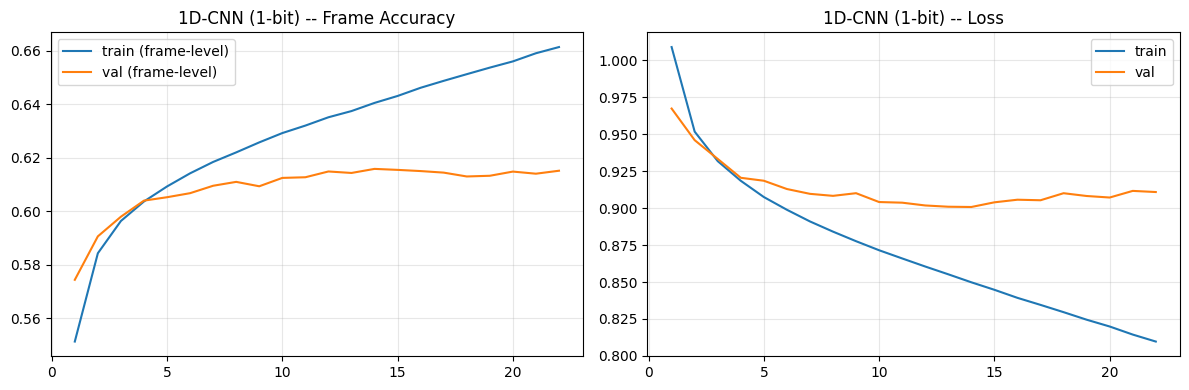

In [17]:
# ============================================================
# [1-bit] 4. Training curves
# ============================================================
hist_df_1 = plot_history(history_1, "1D-CNN (1-bit)")


1D-CNN (1-bit) -- Clip-Level Test Performance
Accuracy   : 0.8975
Precision  : 0.8969
Recall     : 0.8975
F1 (macro) : 0.8965

              precision    recall  f1-score   support

     Command     0.8993    0.8333    0.8651       300
Conversation     0.9333    0.9333    0.9333       300
     Numeric     0.9200    0.9967    0.9568       300
        Read     0.8350    0.8267    0.8308       300

    accuracy                         0.8975      1200
   macro avg     0.8969    0.8975    0.8965      1200
weighted avg     0.8969    0.8975    0.8965      1200



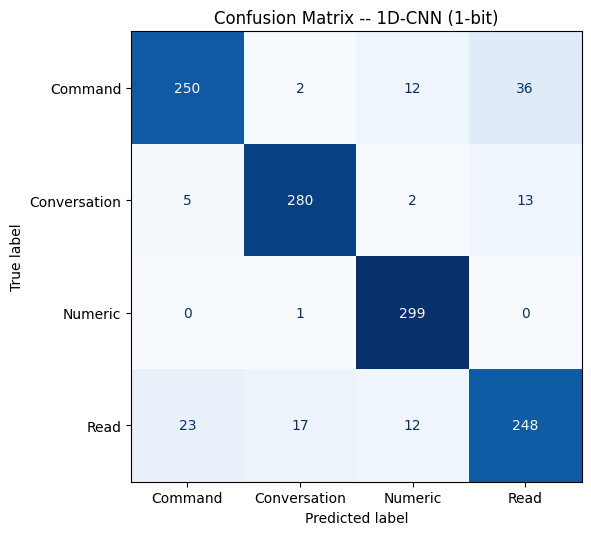

In [18]:
# ============================================================
# [1-bit] 5. Clip-level test evaluation (full report)
# ============================================================
preds_clip_1, probs_clip_1 = predict_clip_level(model_1bit, Xf_test_1, ids_test_1, n_clips=len(X_test_1))
report_1bit = full_clip_report(y_test_1, preds_clip_1, tag="1D-CNN (1-bit)")


---
# Final comparison -- 16-bit vs 1-bit (1D-CNN)
---

In [19]:
# ============================================================
# Comparison -- bootstrap CI + McNemar test + results table
# ============================================================
def bootstrap_ci_paired(labels, preds, metric_fn, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(labels)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        stats.append(metric_fn(labels[idx], preds[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


def mcnemar_test(labels, preds_a, preds_b):
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum(correct_a & ~correct_b))
    n10 = int(np.sum(~correct_a & correct_b))
    if n01 + n10 == 0:
        return 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return 1 - chi2.cdf(stat, df=1)


acc_ci_16 = bootstrap_ci_paired(report_16bit["labels"], report_16bit["preds"], accuracy_score)
acc_ci_1 = bootstrap_ci_paired(report_1bit["labels"], report_1bit["preds"], accuracy_score)

print(f"16-bit test accuracy 95% bootstrap CI: mean={acc_ci_16[0]:.4f} [{acc_ci_16[1]:.4f}, {acc_ci_16[2]:.4f}]")
print(f"1-bit  test accuracy 95% bootstrap CI: mean={acc_ci_1[0]:.4f} [{acc_ci_1[1]:.4f}, {acc_ci_1[2]:.4f}]")

if len(report_16bit["labels"]) == len(report_1bit["labels"]):
    p_val = mcnemar_test(report_16bit["labels"], report_16bit["preds"], report_1bit["preds"])
    print(f"McNemar test (16-bit vs 1-bit predictions), p-value = {p_val:.4g}")

final_table = pd.DataFrame([
    {"Model": "1D-CNN (Baghel et al. 2019, from scratch)", "Condition": "16-bit",
     "Accuracy": report_16bit["accuracy"], "Macro-F1": report_16bit["f1_macro"]},
    {"Model": "1D-CNN (Baghel et al. 2019, from scratch)", "Condition": "1-bit",
     "Accuracy": report_1bit["accuracy"], "Macro-F1": report_1bit["f1_macro"]},
])
print(final_table.to_string(index=False))
final_table.to_csv(os.path.join(OUT_DIR, "final_results_table_1dcnn.csv"), index=False)

# Optional: compare against previously saved SSL-model results tables if present.
for name, path in [
    ("Wav2Vec2", "/kaggle/working/results/final_results_table.csv"),
    ("WavLM", "/kaggle/working/results_wavlm/final_results_table_wavlm.csv"),
]:
    if os.path.exists(path):
        t = pd.read_csv(path)
        t = t[~t["Model"].str.contains("MFCC")]
        print(f"\n{name} results (from prior run):")
        print(t.to_string(index=False))

print(f"\nArtifacts written to: {OUT_DIR}")


16-bit test accuracy 95% bootstrap CI: mean=0.9899 [0.9842, 0.9950]
1-bit  test accuracy 95% bootstrap CI: mean=0.8973 [0.8800, 0.9142]
McNemar test (16-bit vs 1-bit predictions), p-value = 0
                                    Model Condition  Accuracy  Macro-F1
1D-CNN (Baghel et al. 2019, from scratch)    16-bit    0.9900  0.989983
1D-CNN (Baghel et al. 2019, from scratch)     1-bit    0.8975  0.896502

Artifacts written to: /kaggle/working/results_1dcnn


## Notes before you trust these numbers

- This model is trained **from scratch** -- no pretrained weights, unlike the Wav2Vec2 /
  WavLM / HuBERT notebooks. A meaningfully lower accuracy than those is expected and is not
  itself a bug; the interesting comparison is *how much* lower, and whether the classical
  spectral-frame + shallow-CNN approach holds up better or worse than the SSL models under
  the 1-bit condition specifically.
- Frame count per clip is printed in Section 2 of each part -- sanity-check it's in the
  range you expect for a 1-second clip at 20 ms/10 ms framing (~99 frames) before trusting
  downstream numbers.
- Same single-seed caveat as every other notebook in this series: rerun with a few more
  seeds before reporting mean accuracy as a stable result.
- The `assert flat_dim == 4736` in the model definition is a built-in fidelity check against
  the paper's own reported number -- if that assertion ever fails after you change
  `N_FREQ`/`KERNEL_SIZE`/`POOL_SIZE`, the architecture no longer matches Baghel et al. (2019).
